# O*NET Database Analysis

This notebook performs exploratory data analysis on the relevant files from the O*NET 29.0 Database.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [2]:
onet_dir = Path("../data/raw/onet_29_0_database/db_29_0_text")

print("Available files in O*NET Database:")
if onet_dir.exists():
    files = list(onet_dir.glob("*.txt"))
    for f in files[:10]:
        print(f.name)
    if len(files) > 10:
        print(f"... and {len(files) - 10} more files.")
else:
    print("Directory not found.")

Available files in O*NET Database:
Abilities to Work Activities.txt
Abilities to Work Context.txt
Abilities.txt
Alternate Titles.txt
Basic Interests to RIASEC.txt
Content Model Reference.txt
DWA Reference.txt
Education, Training, and Experience Categories.txt
Education, Training, and Experience.txt
Emerging Tasks.txt
... and 31 more files.


In [3]:
occ_path = onet_dir / "Occupation Data.txt"
skills_path = onet_dir / "Skills.txt"
tech_path = onet_dir / "Technology Skills.txt"
tasks_path = onet_dir / "Task Statements.txt"
related_path = onet_dir / "Related Occupations.txt"

def load_onet(path):
    if path.exists():
        return pd.read_csv(path, sep="\t")
    return None

df_occ = load_onet(occ_path)
df_skills = load_onet(skills_path)
df_tech = load_onet(tech_path)
df_tasks = load_onet(tasks_path)
df_related = load_onet(related_path)

### Occupation Data

In [4]:
if df_occ is not None:
    print("Shape:", df_occ.shape)
    display(df_occ.head())
    print("Missing Values:\n", df_occ.isnull().sum())

Shape: (1016, 3)


,O*NET-SOC Code,Title,Description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes..."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici..."


Missing Values:
 O*NET-SOC Code    0
Title             0
Description       0
dtype: int64


### Skills Data

Shape: (61530, 13)


,O*NET-SOC Code,Element ID,Element Name,Scale ID,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,2.A.1.a,Reading Comprehension,IM,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst
1,11-1011.00,2.A.1.a,Reading Comprehension,LV,4.62,8,0.1830,4.2664,4.9836,N,N,08/2023,Analyst
2,11-1011.00,2.A.1.b,Active Listening,IM,4.00,8,0.0000,4.0000,4.0000,N,NaN,08/2023,Analyst
3,11-1011.00,2.A.1.b,Active Listening,LV,4.75,8,0.1637,4.4292,5.0708,N,N,08/2023,Analyst
4,11-1011.00,2.A.1.c,Writing,IM,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst


Unique Skills: 35


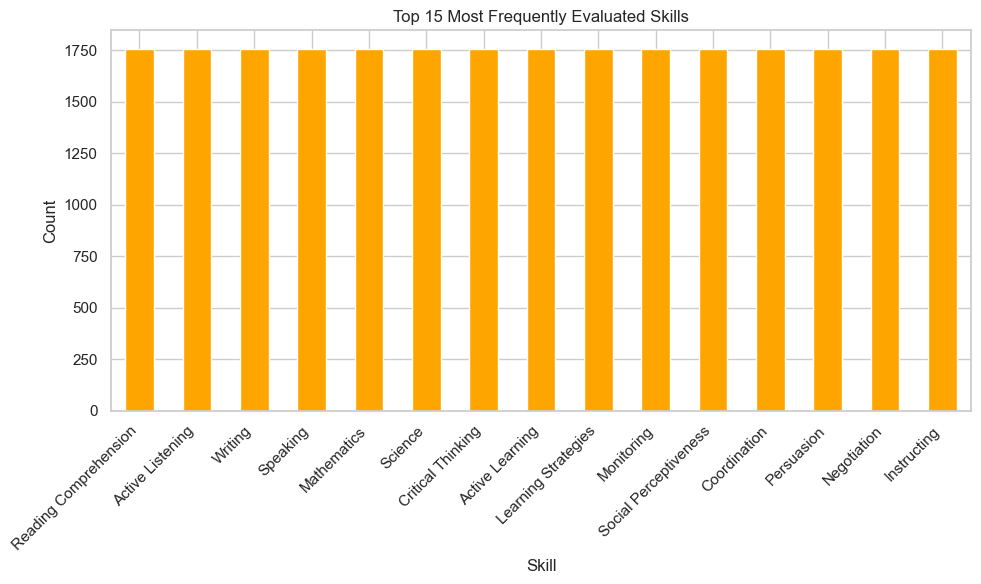

In [5]:
if df_skills is not None:
    print("Shape:", df_skills.shape)
    display(df_skills.head())
    print("Unique Skills:", df_skills['Element Name'].nunique())
    
    plt.figure(figsize=(10, 6))
    df_skills['Element Name'].value_counts().head(15).plot(kind='bar', color='orange')
    plt.title("Top 15 Most Frequently Evaluated Skills")
    plt.xlabel("Skill")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Technology Skills

Shape: (32470, 6)


,O*NET-SOC Code,Example,Commodity Code,Commodity Title,Hot Technology,In Demand
0,11-1011.00,Adobe Acrobat,43232202,Document management software,Y,N
1,11-1011.00,AdSense Tracker,43232306,Data base user interface and query software,N,N
2,11-1011.00,Atlassian JIRA,43232201,Content workflow software,Y,N
3,11-1011.00,Blackbaud The Raiser's Edge,43232303,Customer relationship management CRM software,N,N
4,11-1011.00,ComputerEase construction accounting software,43231601,Accounting software,N,N


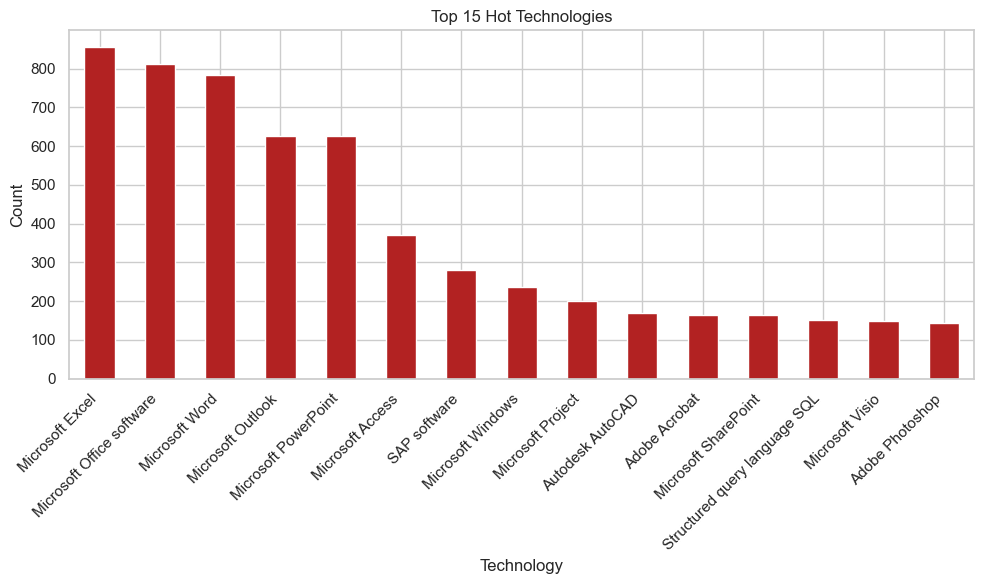

In [6]:
if df_tech is not None:
    print("Shape:", df_tech.shape)
    display(df_tech.head())
    
    plt.figure(figsize=(10, 6))
    df_tech[df_tech['Hot Technology'] == 'Y']['Example'].value_counts().head(15).plot(kind='bar', color='firebrick')
    plt.title("Top 15 Hot Technologies")
    plt.xlabel("Technology")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Task Statements

In [7]:
if df_tasks is not None:
    print("Shape:", df_tasks.shape)
    display(df_tasks.head(2))
    print("Total unique tasks:", df_tasks['Task'].nunique())

Shape: (18796, 7)


,O*NET-SOC Code,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent
1,11-1011.00,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent


Total unique tasks: 17536


### Related Occupations

In [8]:
if df_related is not None:
    print("Shape:", df_related.shape)
    display(df_related.head(2))
    print("Missing Values:\n", df_related.isnull().sum())

Shape: (18460, 4)


,O*NET-SOC Code,Related O*NET-SOC Code,Relatedness Tier,Index
0,11-1011.00,11-1021.00,Primary-Short,1
1,11-1011.00,11-2032.00,Primary-Short,2


Missing Values:
 O*NET-SOC Code            0
Related O*NET-SOC Code    0
Relatedness Tier          0
Index                     0
dtype: int64


### Conclusion

- The O*NET database provides a highly structured and relational dataset linking occupations to skills, technology, tasks, and related roles.
- Missing values are minimal across the key files.
- The `Skills.txt` file is highly structured with standard scales.
- The `Technology Skills.txt` dataset is rich with "Hot Technology" flags that are useful for identifying high-demand skills.
- Using this dataset for modeling will require joining tables via the `O*NET-SOC Code`.